In [ ]:
#data cleaning
from google.colab import files
uploaded = files.upload()

Saving heart_disease.csv to heart_disease.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('heart_disease.csv')
df.head()


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.info()
df.describe()
df.columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

(10000, 21)

In [ ]:
df.dtypes

,0
Age,float64
Gender,object
Blood Pressure,float64
Cholesterol Level,float64
Exercise Habits,object
Smoking,object
Family Heart Disease,object
Diabetes,object
BMI,float64
High Blood Pressure,object


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
numeric_cols = ['age', 'blood_pressure', 'cholesterol_level', 'bmi',
                'sleep_hours', 'triglyceride_level', 'fasting_blood_sugar',
                'crp_level', 'homocysteine_level']

categorical_cols = [col for col in df.columns if col not in numeric_cols]


In [ ]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')   # ensure numeric
    df[col].fillna(df[col].mean(), inplace=True)        # fill NaN with mean
    df[col] = df[col].round(0).astype(int)             # round and convert to int


/tmp/ipykernel_354/2884424871.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)        # fill NaN with mean
/tmp/ipykernel_354/2884424871.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [ ]:
for col in categorical_cols:
    df[col] = df[col].str.strip()                        # remove extra spaces
    df[col].fillna(df[col].mode()[0], inplace=True)      # fill NaN with mode


/tmp/ipykernel_354/3611211369.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)      # fill NaN with mode


In [ ]:
#Encode categorical columns for ML
# Exclude target column from encoding
target_col = 'heart_disease_status'
categorical_to_encode = [col for col in categorical_cols if col != target_col]

In [ ]:
df = pd.get_dummies(df, columns=categorical_to_encode, drop_first=True)

In [ ]:
#Verify the cleaned dataset
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   age                         10000 non-null  int64 
 1   blood_pressure              10000 non-null  int64 
 2   cholesterol_level           10000 non-null  int64 
 3   bmi                         10000 non-null  int64 
 4   sleep_hours                 10000 non-null  int64 
 5   triglyceride_level          10000 non-null  int64 
 6   fasting_blood_sugar         10000 non-null  int64 
 7   crp_level                   10000 non-null  int64 
 8   homocysteine_level          10000 non-null  int64 
 9   heart_disease_status        10000 non-null  object
 10  gender_Male                 10000 non-null  bool  
 11  exercise_habits_Low         10000 non-null  bool  
 12  exercise_habits_Medium      10000 non-null  bool  
 13  smoking_Yes                 10000 non-null  boo

In [ ]:
df.to_csv("heart_disease_cleaned.csv", index=False)

In [ ]:
#Modeling (training the data)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# Step 2: Separate features (X) and target (y)
X = df.drop('heart_disease_status', axis=1)   # all columns except 'target'
y = df['heart_disease_status']                # only the target column

# Step 3: Scale the features (standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Shapes of data:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes of data:
X_train: (8000, 24)
X_test: (2000, 24)
y_train: (8000,)
y_test: (2000,)


In [ ]:
#Evaluation & Interpretability
from sklearn.linear_model import LogisticRegression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Step 6: Create and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Make predictions
y_pred = model.predict(X_test)

# Step 8: Evaluate the model
print("Model Evaluation Results:")
print("-----------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Evaluation Results:
-----------------------------
Accuracy: 0.8065

Confusion Matrix:
 [[1613    0]
 [ 387    0]]

Classification Report:
               precision    recall  f1-score   support

          No       0.81      1.00      0.89      1613
         Yes       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


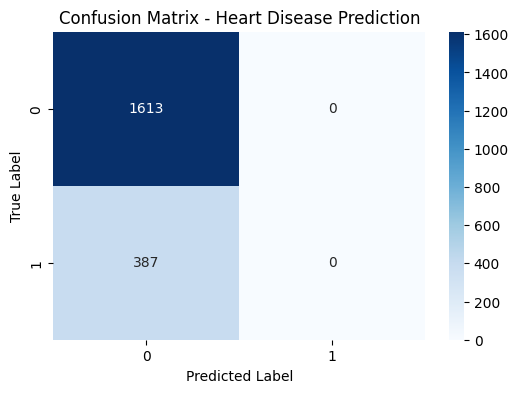

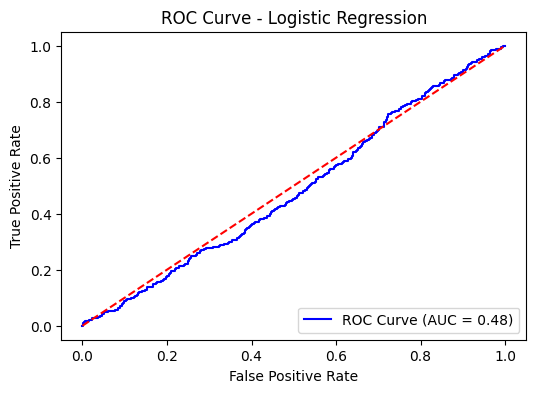

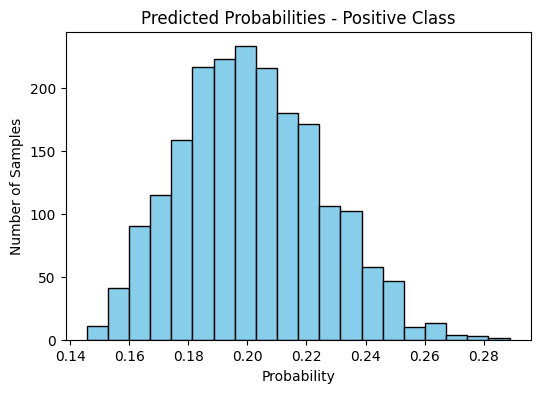

In [ ]:
#Visualization for Logistic Regression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Convert y_test to binary (0 for 'No', 1 for 'Yes')
y_test_binary = np.where(y_test == 'Yes', 1, 0)

# Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Heart Disease Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = roc_auc_score(y_test_binary, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

# Histogram of Predicted Probabilities
plt.figure(figsize=(6,4))
plt.hist(y_prob, bins=20, color='skyblue', edgecolor='black')
plt.title("Predicted Probabilities - Positive Class")
plt.xlabel("Probability")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
#Testing
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
from sklearn.model_selection import cross_val_score


Test Accuracy: 0.8065


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-Validation Scores: [0.8 0.8 0.8 0.8 0.8]
Mean CV Accuracy: 0.8


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#Example new patient data
new_data = pd.DataFrame({
    'Age': [55],
    'Gender': ['Male'],
    'Blood Pressure': [140],
    'Cholesterol Level': [230],
    'Exercise Habits': ['Regular'],
    'Smoking': ['No'],
    'Family Heart Disease': ['Yes'],
    'Diabetes': ['No'],
    'BMI': [28.5],
    'High Blood Pressure': ['Yes'],
    'Low HDL Cholesterol': ['No'],
    'High LDL Cholesterol': ['Yes'],
    'Alcohol Consumption': ['Moderate'],
    'Stress Level': ['High'],
    'Sleep Hours': [6],
    'Sugar Consumption': ['Medium'],
    'Triglyceride Level': [150],
    'Fasting Blood Sugar': [110],
    'CRP Level': [3.2],
    'Homocysteine Level': [11.5]
})

#Recreate preprocessing (encoding)
# You must use the same encoding as used for X during training
X_encoded = pd.get_dummies(X)  # encode your original training data again
feature_columns = X_encoded.columns  # save column names

# Convert new sample to same format
new_data_encoded = pd.get_dummies(new_data)
new_data_encoded = new_data_encoded.reindex(columns=feature_columns, fill_value=0)

#Apply the same scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)  # fit on full training data
new_data_scaled = scaler.transform(new_data_encoded)

# Predict using your model
y_prob = model.predict_proba(new_data_scaled)[:, 1]
y_pred = model.predict(new_data_scaled)

# Show results
print("Predicted Probability of Heart Disease:", round(y_prob[0], 3))
print("Predicted Class:", "Heart Disease" if y_pred[0] == 1 else "No Heart Disease")


Predicted Probability of Heart Disease: 0.261
Predicted Class: No Heart Disease


In [ ]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

# Set threshold for small differences
tolerance = 0.02

if train_acc - test_acc > tolerance:
    print("The model may be overfitting.")
elif test_acc - train_acc > tolerance:
    print(" The model may be underfitting.")
else:
    print("The model is performing well and generalizing properly.")



Training Accuracy: 0.80
Testing Accuracy: 0.81
The model is performing well and generalizing properly.


In [ ]:
# Example new high-risk patient
new_data = pd.DataFrame({
    'Age': [60],
    'Gender': ['Male'],
    'Blood Pressure': [165],
    'Cholesterol Level': [290],
    'Exercise Habits': ['None'],
    'Smoking': ['Yes'],
    'Family Heart Disease': ['Yes'],
    'Diabetes': ['Yes'],
    'BMI': [31.5],
    'High Blood Pressure': ['Yes'],
    'Low HDL Cholesterol': ['Yes'],
    'High LDL Cholesterol': ['Yes'],
    'Alcohol Consumption': ['High'],
    'Stress Level': ['High'],
    'Sleep Hours': [4],
    'Sugar Consumption': ['High'],
    'Triglyceride Level': [230],
    'Fasting Blood Sugar': [160],
    'CRP Level': [6.2],
    'Homocysteine Level': [18.5]
})

# 1️⃣ Clean column names same way as training
new_data.columns = new_data.columns.str.strip().str.lower().str.replace(' ', '_')

# 2️⃣ Encode exactly like training
new_data_encoded = pd.get_dummies(new_data)
new_data_encoded = new_data_encoded.reindex(columns=feature_columns, fill_value=0)

# 3️⃣ Scale using same scaler
new_data_scaled = scaler.transform(new_data_encoded)

# Predict
y_prob = model.predict_proba(new_data_scaled)[:, 1]
y_pred = model.predict(new_data_scaled)

print("Predicted Probability of Heart Disease:", round(y_prob[0], 3))
print("Predicted Class:", "Heart Disease" if y_pred[0] == 1 else "No Heart Disease")


Predicted Probability of Heart Disease: 0.199
Predicted Class: No Heart Disease
